### Adding Descriptors and Splittiing Dataset

In [49]:
import pandas as pd

df= pd.read_csv('data.csv')

df.head()


,Chemical Name,SMILES,Radical Name,Enthalpy,Activation Energy,Temperature,Bond Dissociation Energy,Chemical Group,PH,No,Resource:,smiles_valid,HOMO_predicted,LUMO_predicted,HOMO_LUMO_gap_predicted,log_k,Chemical Group Encoded,Reaction Type_Hydrogen Abstraction,Reaction Type_nan,Radical Name Encoded
0,Pentabromoplatinate(III) ion,[Br][Pt+3]([Br])([Br])([Br])[Br],RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,True,-7.040389,-1.436763,5.603626,8.397940,3,0.0,1.0,2
1,Copper(I) ion,[Cu+],RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,True,-6.625673,0.554958,7.180631,9.000000,3,0.0,1.0,2
2,"2,2'-Azinobis(3-ethylbenzothiazoline-6-sulfona...",CCn1/c(=N\N=c2\sc3cc(S(=O)(=O)[O-])ccc3n2CC)sc...,RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,True,-5.526707,-2.290562,3.236145,9.255273,3,0.0,1.0,2
3,"2,6-Di-tert-butyl-4-methoxyphenol",COc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,True,-5.580419,0.085415,5.665834,5.041401,3,0.0,1.0,2
4,"2,6-Di-tert-butyl-4-methylphenol",Cc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,RO2*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,True,-5.703898,0.133025,5.836923,4.380247,3,0.0,1.0,2


In [50]:
print(df['Radical Name'].value_counts())

df= df.drop(columns=['No', "Resource:"])

remove_list = [
    "tert-RO*",
    "RO2**",
    "HO*",
    "sec-RO*",
    "Ar-O*"
]

# drop rows where Radical Name matches any in the list
df = df[~df["Radical Name"].isin(remove_list)]


Radical Name
sec-RO2*     432
RO2*         430
tert-RO2*    345
tert-RO*       2
RO2**          1
HO*            1
sec-RO*        1
Ar-O*          1
Name: count, dtype: int64


In [51]:
print(df['Radical Name'].value_counts())

Radical Name
sec-RO2*     432
RO2*         430
tert-RO2*    345
Name: count, dtype: int64


In [52]:
!pip install rdkit

In [53]:

import numpy as np

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit import DataStructs

In [54]:
df['Mol'] = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))
# Remove invalid molecules
df = df[df['Mol'].notnull()].reset_index(drop=True)

In [55]:
def get_morgan_fp(mol, radius=2, nBits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

    arr = np.zeros((nBits,))
    DataStructs.ConvertToNumpyArray(fp, arr)

    return arr

df['Morgan_FP'] = df['Mol'].apply(get_morgan_fp)

[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerator
[15:42:05] DEPRECATION WARNING: please use MorganGenerat

In [56]:
descriptor_names = [d[0] for d in Descriptors._descList]

def get_descriptors(mol):
    return [getattr(Descriptors, name)(mol) for name in descriptor_names]

df['Descriptors'] = df['Mol'].apply(get_descriptors)

In [57]:
fp_matrix = np.vstack(df['Morgan_FP'].values)
desc_matrix = np.vstack(df['Descriptors'].values)

# Combine features (FINAL ML MATRIX)
X = np.hstack([fp_matrix, desc_matrix])

In [58]:
def get_radical_group(radical):
    if pd.isna(radical):
        return None

    base = radical.replace('sec-', '').replace('tert-', '').replace('*', '')


In [59]:
df['Feature_Vector'] = list(X)

### change radical datasets

In [60]:
newdf= df.copy()

In [61]:
newdf.shape

(1207, 22)

In [62]:
newdf.head()

,Chemical Name,SMILES,Radical Name,Enthalpy,Activation Energy,Temperature,Bond Dissociation Energy,Chemical Group,PH,smiles_valid,...,HOMO_LUMO_gap_predicted,log_k,Chemical Group Encoded,Reaction Type_Hydrogen Abstraction,Reaction Type_nan,Radical Name Encoded,Mol,Morgan_FP,Descriptors,Feature_Vector
0,Pentabromoplatinate(III) ion,[Br][Pt+3]([Br])([Br])([Br])[Br],RO2*,NaN,NaN,NaN,NaN,NaN,NaN,True,...,5.603626,8.397940,3,0.0,1.0,2,<rdkit.Chem.rdchem.Mol object at 0x7960b1ed06d0>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.3319444444444444, 3.3319444444444444, 2.487...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Copper(I) ion,[Cu+],RO2*,NaN,NaN,NaN,NaN,NaN,NaN,True,...,7.180631,9.000000,3,0.0,1.0,2,<rdkit.Chem.rdchem.Mol object at 0x7960976244a0>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.3472819583833593, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"2,2'-Azinobis(3-ethylbenzothiazoline-6-sulfona...",CCn1/c(=N\N=c2\sc3cc(S(=O)(=O)[O-])ccc3n2CC)sc...,RO2*,NaN,NaN,NaN,NaN,NaN,NaN,True,...,3.236145,9.255273,3,0.0,1.0,2,<rdkit.Chem.rdchem.Mol object at 0x796097624ac0>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[11.331998303119995, 11.331998303119995, 0.309...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,"2,6-Di-tert-butyl-4-methoxyphenol",COc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,RO2*,NaN,NaN,NaN,NaN,NaN,NaN,True,...,5.665834,5.041401,3,0.0,1.0,2,<rdkit.Chem.rdchem.Mol object at 0x796097624510>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[10.189597033257748, 10.189597033257748, 0.042...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"2,6-Di-tert-butyl-4-methylphenol",Cc1cc(C(C)(C)C)cc(C(C)(C)C)c1O,RO2*,NaN,NaN,NaN,NaN,NaN,NaN,True,...,5.836923,4.380247,3,0.0,1.0,2,<rdkit.Chem.rdchem.Mol object at 0x796097624740>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[10.123347033257748, 10.123347033257748, 0.017...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [63]:
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import AllChem

fps = list(newdf['Morgan_FP'])

In [64]:
from rdkit import Chem
from rdkit.Chem import AllChem

def get_fp(mol):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)

fps = [get_fp(mol) for mol in newdf['Mol']]

[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerator
[15:42:22] DEPRECATION WARNING: please use MorganGenerat

#### change Clustering Cutoff on last line if required

In [65]:
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina

def butina_cluster(fps, cutoff=0.3):
    dists = []

    for i in range(1, len(fps)):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])

    clusters = Butina.ClusterData(
        dists,
        len(fps),
        cutoff,
        isDistData=True
    )

    return clusters

clusters = butina_cluster(fps, cutoff=0.45)   # lower the value larger no of cluster, smaller the size of cluster

In [66]:
print("\n================ CLUSTER SUMMARY ================\n")

n_clusters = len(clusters)
print(f"Total clusters formed: {n_clusters}")
print(f"Total molecules: {len(newdf)}")

print("\nCluster sizes:")
for i, cluster in enumerate(clusters):
    print(f"Cluster {i}: {len(cluster)} molecules")

print("\nLargest clusters:")
largest = sorted(clusters, key=len, reverse=True)[:5]
for i, cluster in enumerate(largest):
    print(f"Cluster size {len(cluster)}")


================ CLUSTER SUMMARY ================

Total clusters formed: 211
Total molecules: 1207

Cluster sizes:
Cluster 0: 46 molecules
Cluster 1: 44 molecules
Cluster 2: 36 molecules
Cluster 3: 26 molecules
Cluster 4: 30 molecules
Cluster 5: 29 molecules
Cluster 6: 27 molecules
Cluster 7: 12 molecules
Cluster 8: 19 molecules
Cluster 9: 19 molecules
Cluster 10: 18 molecules
Cluster 11: 23 molecules
Cluster 12: 22 molecules
Cluster 13: 7 molecules
Cluster 14: 13 molecules
Cluster 15: 6 molecules
Cluster 16: 17 molecules
Cluster 17: 16 molecules
Cluster 18: 16 molecules
Cluster 19: 8 molecules
Cluster 20: 15 molecules
Cluster 21: 9 molecules
Cluster 22: 14 molecules
Cluster 23: 13 molecules
Cluster 24: 13 molecules
Cluster 25: 13 molecules
Cluster 26: 12 molecules
Cluster 27: 6 molecules
Cluster 28: 12 molecules
Cluster 29: 6 molecules
Cluster 30: 12 molecules
Cluster 31: 12 molecules
Cluster 32: 12 molecules
Cluster 33: 12 molecules
Cluster 34: 12 molecules
Cluster 35: 10 molecules

In [67]:
import numpy as np

labels = np.zeros(len(newdf), dtype=int)

for cid, cluster in enumerate(clusters):
    for idx in cluster:
        labels[idx] = cid

newdf['Cluster'] = labels

#### Change cluster ID Here

In [68]:
cluster_id = 0
cluster_df = newdf[newdf['Cluster'] == cluster_id].reset_index(drop=True)

In [69]:
### if you want to see only unique structures

#cluster_df_unique = cluster_df.drop_duplicates(subset='SMILES').reset_index(drop=True)

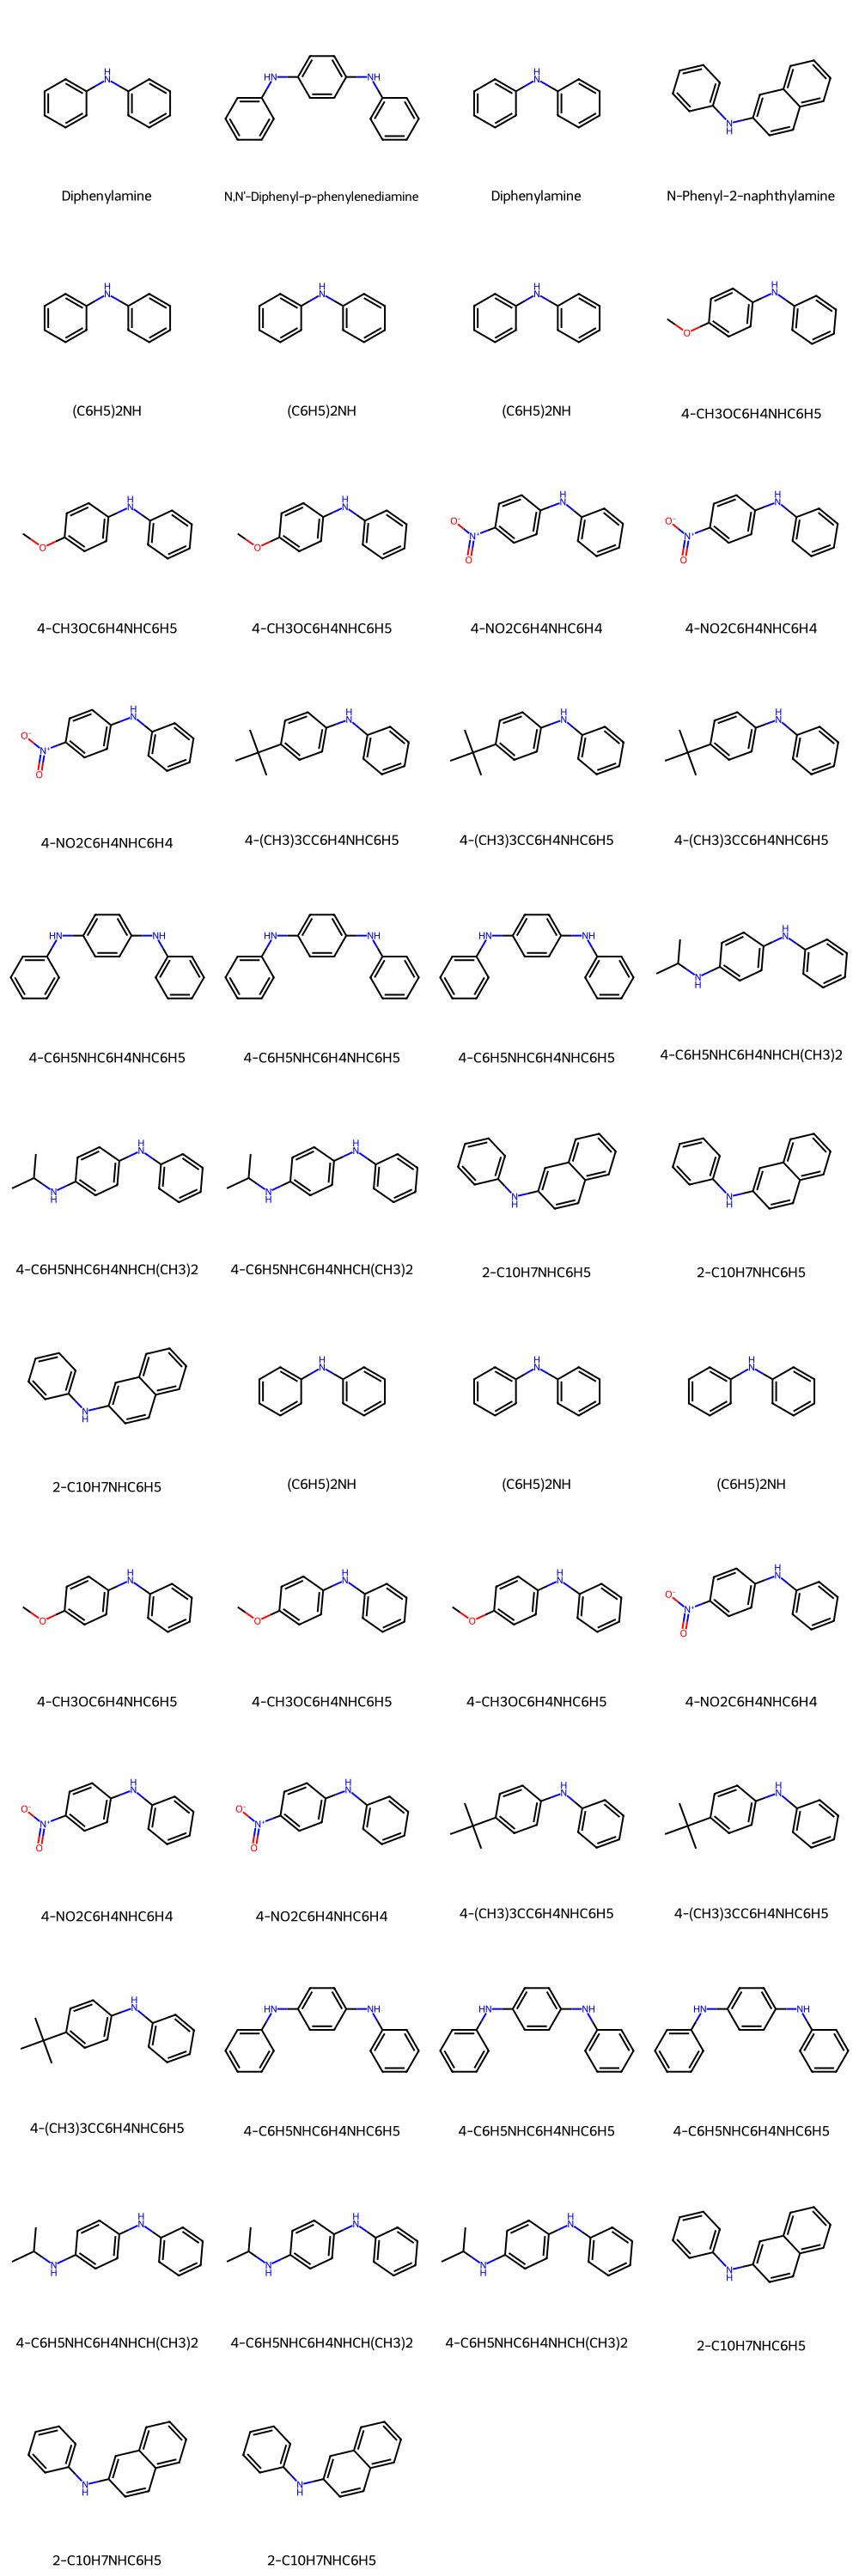

In [70]:
from rdkit.Chem import Draw

mols = cluster_df['Mol'].tolist()

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(250, 250),
    legends=cluster_df['Chemical Name'].tolist()
)

img

In [71]:
display(cluster_df)

,Chemical Name,SMILES,Radical Name,Enthalpy,Activation Energy,Temperature,Bond Dissociation Energy,Chemical Group,PH,smiles_valid,...,log_k,Chemical Group Encoded,Reaction Type_Hydrogen Abstraction,Reaction Type_nan,Radical Name Encoded,Mol,Morgan_FP,Descriptors,Feature_Vector,Cluster
0,Diphenylamine,c1ccc(Nc2ccccc2)cc1,sec-RO2*,NaN,NaN,298.0,NaN,NaN,NaN,True,...,6.477122,3,0.0,1.0,5,<rdkit.Chem.rdchem.Mol object at 0x7960972766c0>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.303888888888889, 3.303888888888889, 1.11916...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
1,"N,N'-Diphenyl-p-phenylenediamine",c1ccc(Nc2ccc(Nc3ccccc3)cc2)cc1,sec-RO2*,NaN,NaN,298.0,NaN,NaN,NaN,True,...,7.602060,3,0.0,1.0,5,<rdkit.Chem.rdchem.Mol object at 0x796097276730>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.3671997039556567, 3.3671997039556567, 1.078...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
2,Diphenylamine,c1ccc(Nc2ccccc2)cc1,tert-RO2*,NaN,6.5,200.0,NaN,NaN,NaN,True,...,2.964731,3,0.0,1.0,7,<rdkit.Chem.rdchem.Mol object at 0x796096f28120>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.303888888888889, 3.303888888888889, 1.11916...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
3,N-Phenyl-2-naphthylamine,c1ccc(Nc2ccc3ccccc3c2)cc1,tert-RO2*,NaN,9.5,200.0,NaN,NaN,NaN,True,...,2.898725,3,0.0,1.0,7,<rdkit.Chem.rdchem.Mol object at 0x796096f28190>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.396037414965986, 3.396037414965986, 1.11368...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
4,(C6H5)2NH,c1ccc(Nc2ccccc2)cc1,RO2*,-4.3,17.8,400.0,364.7,Amine,NaN,True,...,5.672100,0,0.0,0.0,2,<rdkit.Chem.rdchem.Mol object at 0x79609708e500>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.303888888888889, 3.303888888888889, 1.11916...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
5,(C6H5)2NH,c1ccc(Nc2ccccc2)cc1,sec-RO2*,-0.8,19.5,400.0,364.7,Amine,NaN,True,...,5.447161,0,0.0,0.0,5,<rdkit.Chem.rdchem.Mol object at 0x79609708e570>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.303888888888889, 3.303888888888889, 1.11916...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
6,(C6H5)2NH,c1ccc(Nc2ccccc2)cc1,tert-RO2*,6.1,22.8,400.0,364.7,Amine,NaN,True,...,5.041401,0,0.0,0.0,7,<rdkit.Chem.rdchem.Mol object at 0x79609708e5e0>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.303888888888889, 3.303888888888889, 1.11916...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
7,4-CH3OC6H4NHC6H5,COc1ccc(Nc2ccccc2)cc1,RO2*,-13.1,13.8,400.0,355.9,Amine,NaN,True,...,6.204121,0,0.0,0.0,2,<rdkit.Chem.rdchem.Mol object at 0x79609708eb90>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[5.091604780801209, 5.091604780801209, 0.86908...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
8,4-CH3OC6H4NHC6H5,COc1ccc(Nc2ccccc2)cc1,sec-RO2*,-9.6,15.4,400.0,355.9,Amine,NaN,True,...,5.986773,0,0.0,0.0,5,<rdkit.Chem.rdchem.Mol object at 0x79609708ec00>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[5.091604780801209, 5.091604780801209, 0.86908...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
9,4-CH3OC6H4NHC6H5,COc1ccc(Nc2ccccc2)cc1,tert-RO2*,-2.7,18.6,400.0,355.9,Amine,NaN,True,...,5.568204,0,0.0,0.0,7,<rdkit.Chem.rdchem.Mol object at 0x79609708ec70>,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[5.091604780801209, 5.091604780801209, 0.86908...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0


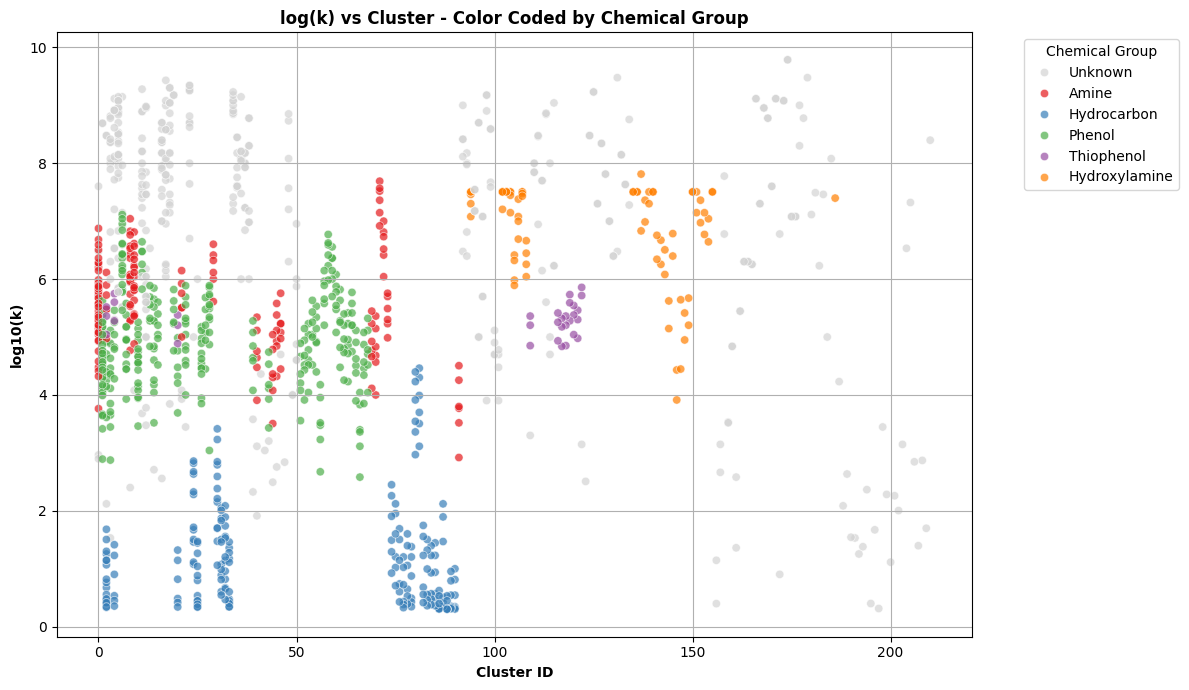

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
plot_df_chemical_group = newdf.copy()
plot_df_chemical_group['Chemical Group'] = plot_df_chemical_group['Chemical Group'].fillna('Unknown')
plot_df_chemical_group = plot_df_chemical_group.dropna(subset=['Cluster', 'log_k'])

# Create a custom palette for Chemical Group
unique_chemical_groups = plot_df_chemical_group['Chemical Group'].unique()
known_groups_chem = [g for g in unique_chemical_groups if g != 'Unknown']
known_colors_chem = sns.color_palette('Set1', n_colors=len(known_groups_chem))

custom_palette_chem = {}
for i, group in enumerate(known_groups_chem):
    custom_palette_chem[group] = known_colors_chem[i]
if 'Unknown' in unique_chemical_groups:
    custom_palette_chem['Unknown'] = 'lightgray'

sns.scatterplot(
    data=plot_df_chemical_group,
    x='Cluster',
    y='log_k',
    hue='Chemical Group',
    palette=custom_palette_chem,
    alpha=0.7
)

plt.xlabel("Cluster ID", fontweight='bold')
plt.ylabel("log10(k)", fontweight='bold')
plt.title("log(k) vs Cluster - Color Coded by Chemical Group", fontweight='bold')
legend = plt.legend(title="Chemical Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [73]:
newdf = newdf[newdf["Radical Name"] != "RO2*"]

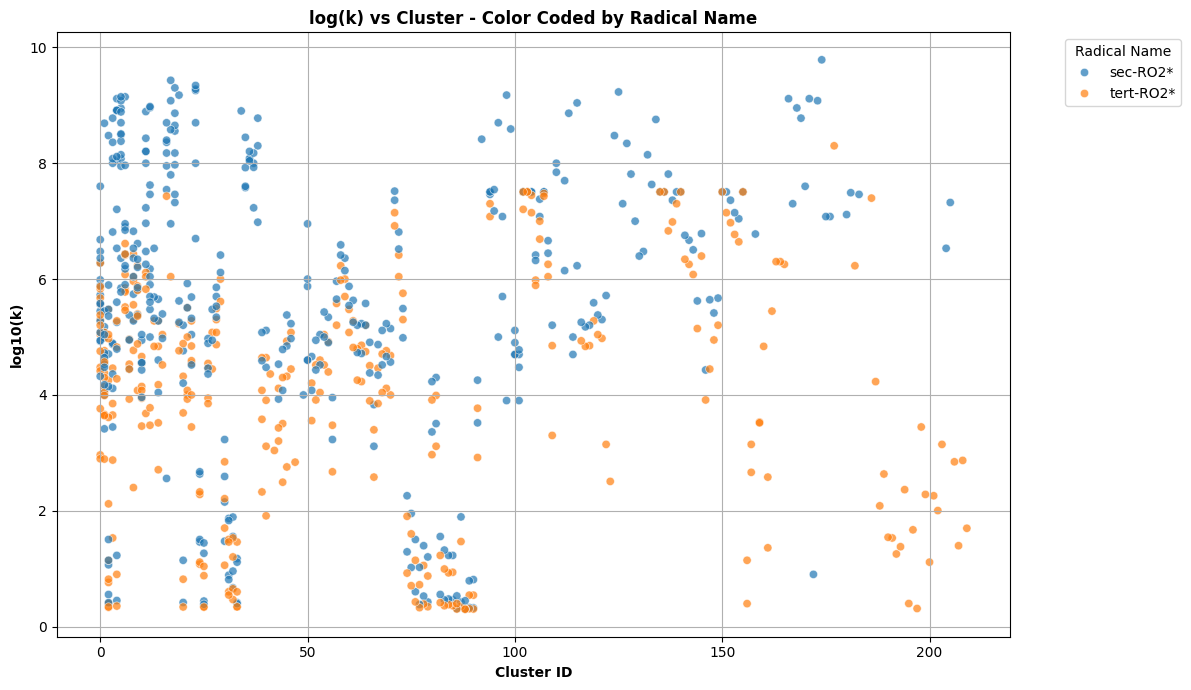

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
plot_df_radical_name = newdf.copy()
plot_df_radical_name['Radical Name'] = plot_df_radical_name['Radical Name'].fillna('Unknown')
plot_df_radical_name = plot_df_radical_name.dropna(subset=['Cluster', 'log_k'])

# Create a custom palette for Radical Name
unique_radical_names = plot_df_radical_name['Radical Name'].unique()
known_names_rad = [n for n in unique_radical_names if n != 'Unknown']

sns.scatterplot(
    data=plot_df_radical_name,
    x='Cluster',
    y='log_k',
    hue='Radical Name',
    alpha=0.7
)

plt.xlabel("Cluster ID", fontweight='bold')
plt.ylabel("log10(k)", fontweight='bold')
plt.title("log(k) vs Cluster - Color Coded by Radical Name", fontweight='bold')
legend = plt.legend(title="Radical Name", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()